In [14]:
import xarray as xr
data_url = 'https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/waposal/MT-S3A.zarr'
ds = xr.open_zarr(data_url, decode_times=False, zarr_format=2)
ds

<xarray.Dataset> Size: 3GB
Dimensions:              (trajectory: 10339, obs: 6263)
Dimensions without coordinates: trajectory, obs
Data variables:
    Dist2coast_20Hz      (trajectory, obs) float32 259MB dask.array<chunksize=(1000, 6263), meta=np.ndarray>
    high_WPD_value_flag  (trajectory, obs) float32 259MB dask.array<chunksize=(1000, 6263), meta=np.ndarray>
    latitude_20Hz        (trajectory, obs) float32 259MB dask.array<chunksize=(1000, 6263), meta=np.ndarray>
    longitude_20Hz       (trajectory, obs) float32 259MB dask.array<chunksize=(1000, 6263), meta=np.ndarray>
    Misfit_20Hz          (trajectory, obs) float32 259MB dask.array<chunksize=(1000, 6263), meta=np.ndarray>
    Sigma0_20Hz          (trajectory, obs) float32 259MB dask.array<chunksize=(1000, 6263), meta=np.ndarray>
    SWH_20Hz             (trajectory, obs) float32 259MB dask.array<chunksize=(1000, 6263), meta=np.ndarray>
    T_20Hz               (trajectory, obs) float32 259MB dask.array<chunksize=(1000, 6263), meta=np.ndarray>
    TAI_Time_20Hz        (trajectory, obs) float32 259MB dask.array<chunksize=(1000, 6263), meta=np.ndarray>
    trajectory_info      (trajectory) <U103 4MB dask.array<chunksize=(1000,), meta=np.ndarray>
    Wave_Power_20Hz      (trajectory, obs) float32 259MB dask.array<chunksize=(1000, 6263), meta=np.ndarray>
Attributes: (12/16)
    Conventions:     CF-1.6/CF-1.7
    feature_type:    trajectory
    start_datetime:  2016-03-13T20:00:32
    end_datetime:    2022-12-31T21:45:36
    created:         2025-11-14T00:00:00Z
    description:     Wave power density, zero-crossing wave period, and signi...
    ...              ...
    min_lon:         -6.0
    min_lat:         30.1
    max_lon:         41.8
    max_lat:         47.4
    crs:             epsg:4326
    referencfe:      https://opensciencedata.esa.int/products/waposal-waves/c...

In [15]:
ds.trajectory_info.values

array(['P_RES_S3A_SR_1_SRA_A__20160313T200006_20160313T200020_20180203T001443_0013_002_014_GPOD_SAR_R_NT_003.nc',
       'P_RES_S3A_SR_1_SRA_A__20160406T080605_20160406T085634_20180203T005835_3029_002_349_GPOD_SAR_R_NT_003.nc',
       'P_RES_S3A_SR_1_SRA_A__20160406T094704_20160406T103733_20180203T012114_3029_002_350_GPOD_SAR_R_NT_003.nc',
       ...,
       'P_RES_S3A_SR_1_SRA_A__20221231T100948_20221231T110018_20230126T130756_3029_094_008_GPOD_SAR_O_NT_004.nc',
       'P_RES_S3A_SR_1_SRA_A__20221231T192514_20221231T201544_20230126T213108_3029_094_013_GPOD_SAR_O_NT_004.nc',
       'P_RES_S3A_SR_1_SRA_A__20221231T210613_20221231T215642_20230126T230552_3028_094_014_GPOD_SAR_O_NT_004.nc'],
      shape=(10339,), dtype='<U103')

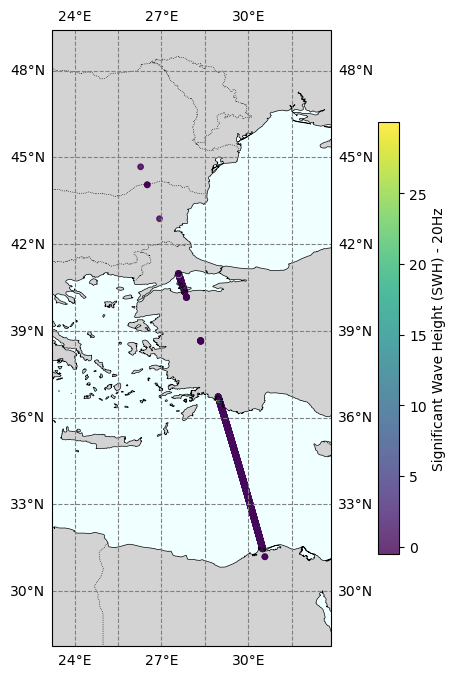

In [17]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

trj_indx = 3
lons = ds.isel(trajectory=trj_indx)['longitude_20Hz'].compute()
lats = ds.isel(trajectory=trj_indx)['latitude_20Hz'].compute()
data_to_plot = ds.isel(trajectory=trj_indx)['SWH_20Hz'].compute() 

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='azure')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, color='gray', linestyle='--')

scatter = ax.scatter(
    lons, lats, 
    c=data_to_plot, 
    cmap='viridis',     
    s=15,               
    transform=ccrs.PlateCarree(), 
    alpha=0.8       
)

cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', pad=0.05, shrink=0.7)
cbar.set_label('Significant Wave Height (SWH) - 20Hz')

ax.set_extent([
    lons.min() - 2, lons.max() + 2, 
    lats.min() - 2, lats.max() + 2
], crs=ccrs.PlateCarree())

plt.show()